# Epic of Sun - Desafio 1
Preprocessing the data in all the scenes
***

This jupyter notebook preprocesses the data to be used in the training phase.

It is divided in 4 parts:
* Loading libraries anda data
* Creating merged images
* Segmenting the data in patches
* Saving the TFRecords for training

***

## Loading libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
from rasterio.windows import Window
from affine import Affine
import tensorflow as tf

import json
import joblib
from pathlib import Path
import os

2026-08-10 04:00:49.964200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786345250.824319  159186 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786345251.087857  159186 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-10 04:00:53.114306: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

## Creating merged files

In [3]:
# Function to merge the 4 bands into a single 4-channel image and return the image and the profile of the first band
def create_merged_scene_file(
	scene_folder, 
	output_filepath, 
	crop=(0.4, 0.7, 0.0, 0.3)):
    """
    Merges individual Sentinel bands (B02, B03, B04, B08) from a scene folder 
    into a single multi-band GeoTIFF file on disk.
    """

    x0, x1, y0, y1 = crop

    scene_folder = Path(scene_folder)
    output_filepath = Path(output_filepath)
    output_filepath.parent.mkdir(parents=True, exist_ok=True)

    band_patterns = {
        "blue": "*B02_10m.jp2",
        "green": "*B03_10m.jp2",
        "red": "*B04_10m.jp2",
        "nir": "*B08_10m.jp2",
    }

    band_files = {}
    for color, pattern in band_patterns.items():
		#matches = list((scene_folder / "bands").glob(pattern))
        matches = list((scene_folder).glob(pattern))
        if not matches:
            raise FileNotFoundError(f"Could not find band file matching {pattern} in {scene_folder / 'bands'}")
        band_files[color] = matches[0]

    arrays = []
    profile = None

    # Open files and read data
    for file in band_files.values():
        with rasterio.open(file) as src:

            width = src.width
            height = src.height

            # Crop window
            window = Window(
                col_off=int(width * x0),
                row_off=int(height * y0),
                width=int(width * (x1 - x0)),
                height=int(height * (y1 - y0))
            )

            # Read only the selected region
            arrays.append(src.read(1, window=window))

            if profile is None:

                profile = src.profile.copy()

                # Update transform for the cropped image
                profile.update({
                    "driver": "GTiff",
                    "width": window.width,
                    "height": window.height,
                    "transform": rasterio.windows.transform(window, src.transform),
                    "count": len(band_patterns),
                    "dtype": rasterio.float32,
                    "compress": "deflate"
                })

    # Write the merged multi-band raster to disk
    with rasterio.open(output_filepath, 'w', **profile) as dst:
        for idx, array in enumerate(arrays, start=1):
            dst.write(array, idx)

    print(f"Merged scene saved to: {output_filepath}")
    return output_filepath

In [4]:
# Processing scenes and creating merged files
crop = (0.35, 0.65, 0.35, 0.65)  # Crop parameters: (x0, x1, y0, y1)
scenes_root = base_path / "data" / "raw"
output_dir = base_path / "data" / "interim"

for folder in scenes_root.iterdir():
    # Only process directories starting with "scene"
    if folder.is_dir() and folder.name.startswith("scene"):
        output_file = output_dir / f"{folder.name}_merged.tif"
        try:
            create_merged_scene_file(
				folder, 
				output_file, 
				crop=crop
				)
            print(f"Successfully merged: {folder.name}\n")
        except FileNotFoundError as e:
            print(f"\nSkipping '{folder.name}': {e}\n")

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene10_merged.tif
Successfully merged: scene10

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene02_merged.tif
Successfully merged: scene02

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene09_merged.tif
Successfully merged: scene09

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene04_merged.tif
Successfully merged: scene04

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene03_merged.tif
Successfully merged: scene03

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene07_merged.tif
Successfully merged: scene07

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene05_merged.tif
Successfully merged: scene05

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene06_merged.tif
Successfully merged: scene06

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/interim/scene

In [5]:
# Checking all cropped scenes in the interim directory
interim_dir = base_path / "data" / "interim"
files = sorted(interim_dir.glob("*_merged.tif"))

print("Merged scenes found:")
for f in files:
    print(" ", f.name)

Merged scenes found:
  scene01_merged.tif
  scene02_merged.tif
  scene03_merged.tif
  scene04_merged.tif
  scene05_merged.tif
  scene06_merged.tif
  scene07_merged.tif
  scene08_merged.tif
  scene09_merged.tif
  scene10_merged.tif


## Segmenting the data in patches

In [6]:
# Function to rasterize the sugarcane mesh for all scenes

def create_scene_mask(merged_tif_path, gdf_mask):
    """
    Rasterizes the vector shapes specifically for the extent, CRS, 
    and resolution of a single merged scene.
    """
    with rasterio.open(merged_tif_path) as src:
        # Align mask CRS to scene CRS if they differ
        if gdf_mask.crs != src.crs:
            gdf_mask_proj = gdf_mask.to_crs(src.crs)
        else:
            gdf_mask_proj = gdf_mask

        # Rasterize shapes into a 2D numpy array matching scene dimensions
        mask_array = rasterize(
            [(geom, 1) for geom in gdf_mask_proj.geometry],
            out_shape=(src.height, src.width),
            transform=src.transform,
            fill=0,
            dtype='uint8'
        )
        
    return mask_array

In [7]:
# Function to clip the vector mask to the spatial extent of one raster scene
def clip_mask_to_scene(gdf, src):
    """
    Clip the vector mask to the spatial extent of one raster scene.
    """

    # Raster bounds
    xmin, ymin, xmax, ymax = src.bounds

    # Bounding box polygon
    bbox = box(xmin, ymin, xmax, ymax)

    # Fast preselection using the spatial index
    idx = list(gdf.sindex.intersection(bbox.bounds))
    gdf_subset = gdf.iloc[idx]

    # Exact clipping
    return gpd.clip(gdf_subset, bbox)

In [8]:
# Paths setup
interim_dir = base_path / "data" / "interim"
mask_file = base_path / "data" / "raw" / "mask" / "sugarcane_mesh.shp"

# Main folder to store extracted patches
patches_base_dir = base_path / "data" / "processed"
patches_base_dir.mkdir(parents=True, exist_ok=True)

# 1. Load vector mask ONCE
gdf_mask = gpd.read_file(mask_file)

patch_size = 128
stride = 64  # 50% overlap / No overlap

total_patches_saved = 0
records = []
scenes_processed = []

# And project the mask to the CRS of the first merged scene 
# (as the yare all on the same CRS, this is done only once for efficiency)
with rasterio.open(next(interim_dir.glob("*_merged.tif"))) as src:
    gdf_mask = gdf_mask.to_crs(src.crs)

# 2. Loop over each merged scene TIF
for merged_tif_path in interim_dir.glob("*_merged.tif"):
    scene_name = merged_tif_path.stem.replace("_merged", "")
    print(f"\nProcessing and saving patches for scene: {scene_name}")
    scenes_processed.append(scene_name)

    # Create scene-specific subfolders for X (images) and y (masks)
    scene_x_dir = patches_base_dir / scene_name / "images"
    scene_y_dir = patches_base_dir / scene_name / "masks"
    scene_x_dir.mkdir(parents=True, exist_ok=True)
    scene_y_dir.mkdir(parents=True, exist_ok=True)

    with rasterio.open(merged_tif_path) as src:
        image_raw = src.read()
        image_meta = src.meta.copy()

	# Keep only polygons intersecting this scene
    gdf_scene = clip_mask_to_scene(gdf_mask, src)

    print(f"Polygons in scene: {len(gdf_scene)}")

    y_mask = rasterize(
		((geom, 1) for geom in gdf_scene.geometry),
		out_shape=(src.height, src.width),
		transform=src.transform,
		all_touched=True,
		fill=0,
		dtype="uint8"
    )

    # Preprocessing / Normalization per scene
    image_normal = image_raw.astype(np.float32)

    # Convert to physical reflectance [0.0, ~1.0+]
    REFLECTANCE_SCALE = 10000.0
    image_float = (image_raw.astype(np.float32) - 1000) / REFLECTANCE_SCALE

    # Clip high-reflectance outliers/clouds to 1.0 (or 1.2)
    image_normal = np.clip(image_float, 0.0, 1.2)

    # Reorder to (H, W, Channels)
    X_data = np.moveaxis(image_normal, 0, -1)

    # Patch Extraction Loop
    h, w, c = X_data.shape
    patch_idx = 0

    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            x_patch = X_data[i : i + patch_size, j : j + patch_size, :]
            y_patch = y_mask[i : i + patch_size, j : j + patch_size]

            # Add channel dimension to y_patch -> (128, 128, 1)
            y_patch = np.expand_dims(y_patch, axis=-1)

            # Optional Filter: Skip empty patches (uncomment if desired)
            # if np.sum(y_patch) == 0:
            #     continue

            # File names matching patch index
            x_filename = scene_x_dir / f"patch_{patch_idx:04d}.npy"
            y_filename = scene_y_dir / f"patch_{patch_idx:04d}.npy"

            # Save patches directly to disk
            np.save(x_filename, x_patch)
            np.save(y_filename, y_patch)

            # Log record with relative paths for portability
            records.append({
                "scene": scene_name,
                "patch_id": patch_idx,
                "row_start": i,
                "col_start": j,
                "x_patch_path": str(x_filename.relative_to(base_path)),
                "y_patch_path": str(y_filename.relative_to(base_path)),
                "sugarcane_pixels": int(np.sum(y_patch))
            })

            patch_idx += 1

    total_patches_saved += patch_idx
    print(f"Saved {patch_idx} patches to {patches_base_dir / scene_name}")

    # Explicit memory cleanup per iteration
    del image_raw, image_normal, X_data, y_mask

print(f"\n--- Complete! Saved {total_patches_saved} total patches across all scenes. ---")


Processing and saving patches for scene: scene02
Polygons in scene: 1757
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene02

Processing and saving patches for scene: scene08
Polygons in scene: 975
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene08

Processing and saving patches for scene: scene03
Polygons in scene: 985
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene03

Processing and saving patches for scene: scene05
Polygons in scene: 1720
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene05

Processing and saving patches for scene: scene04
Polygons in scene: 1763
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene04

Processing and saving patches for scene: scene06
Polygons in scene: 1877
Saved 2500 patches to /home/fdesmello/Git/spacesugar/data/processed/scene06

Processing and saving patches for scene: scene10
Polygons in scene: 1366
Saved 2500 patches to /home/

In [9]:
# Save CSV Index
patch_index = pd.DataFrame(records).sort_values(by=["scene", "patch_id"])
csv_output_path = patches_base_dir / "patch_index.csv"
patch_index.to_csv(csv_output_path, index=False)
print(f"Patch index saved to '{csv_output_path}'")

Patch index saved to '/home/fdesmello/Git/spacesugar/data/processed/patch_index.csv'


In [10]:
# Save General Metadata JSON (dataset-level summary)
metadata = {
    "patch_size": patch_size,
    "stride": stride,
    "overlap_percentage": f"{(1 - stride/patch_size)*100:.0f}%",
    "bands": ["Blue", "Green", "Red", "NIR"],
    "dtype": "float32",
    "normalization": "subtract 1000 divide by 10000 and clip to [0.0, 1.2]",
    "total_patches": len(records),
    "scenes_processed": scenes_processed,
    "source": "Sentinel-2",
    "label_source": "Brazil Sugarcane Mesh 2024"
}

json_output_path = patches_base_dir / "metadata.json"
with open(json_output_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Dataset metadata saved to '{json_output_path}'")

Dataset metadata saved to '/home/fdesmello/Git/spacesugar/data/processed/metadata.json'


In [11]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb

scene                                                    scene01
patch_id                                                    2000
row_start                                                   2560
col_start                                                      0
x_patch_path        data/processed/scene01/images/patch_2000.npy
y_patch_path         data/processed/scene01/masks/patch_2000.npy
sugarcane_pixels                                           11419
Name: 2000, dtype: object

Visualization saved as '/home/fdesmello/Git/spacesugar/figures/patch_image_with_mask.png'


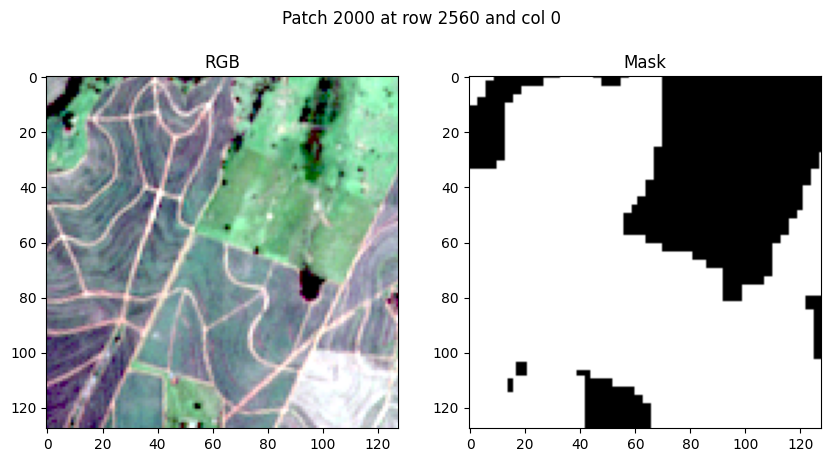

In [12]:
# Patch visualization for sanity check

patch_folder = base_path / "data" / "processed"
patch_index = pd.read_csv(patch_folder / "patch_index.csv")

idx = 2000 # set this to the index of the patch you want to visualize

row = patch_index.iloc[idx]
print(row)

x_patch = np.load(base_path / row["x_patch_path"])
y_patch = np.load(base_path / row["y_patch_path"])

fig, ax = plt.subplots(1, 2, figsize=(10,5))

plt.suptitle(f"Patch {row['patch_id']} at row {row['row_start']} and col {row['col_start']}")

rgb = x_patch[::1, ::1, [2, 1, 0]].copy()
#rgb = rgb[:, :, [2, 1, 0]] # If the bands are in BGR order, use this line instead to convert to RGB
rgb = stretch_rgb(rgb)

ax[0].imshow(rgb)
ax[0].set_title("RGB")

ax[1].imshow(y_patch, cmap="gray")
ax[1].set_title("Mask")

file_path = base_path / "figures" / "patch_image_with_mask.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")

plt.show()

## Saving in TFRecords

In [13]:
# Select the scenes for training, validation, and testing
train_scenes = ["scene01", "scene02", "scene03", "scene04", "scene05", "scene10"]
val_scenes   = ["scene07", "scene08"]
test_scenes  = ["scene09", "scene06"]

In [14]:
# Get the unique scene names
scenes = patch_index["scene"].unique()

# Select patches belonging to those scenes
train_df = patch_index[
    patch_index["scene"].isin(train_scenes)
].reset_index(drop=True)

val_df = patch_index[
    patch_index["scene"].isin(val_scenes)
].reset_index(drop=True)

test_df = patch_index[
    patch_index["scene"].isin(test_scenes)
].reset_index(drop=True)

In [15]:
# Show the number of patches for each scene
print("\nTraining")
print(train_df.groupby("scene").size())

print("\nValidation")
print(val_df.groupby("scene").size())

print("\nTesting")
print(test_df.groupby("scene").size())


Training
scene
scene01    2500
scene02    2500
scene03    2500
scene04    2500
scene05    2500
scene10    2500
dtype: int64

Validation
scene
scene07    2500
scene08    2500
dtype: int64

Testing
scene
scene06    2500
scene09    2500
dtype: int64


In [16]:
# Show the number of patches for each scene and the mean sugarcane pixels
for scene in scenes:
	print(f"\nScene: {scene}")
	scene_df = patch_index[patch_index["scene"] == scene]
	print(scene_df.groupby("scene").size())
	print(scene_df["sugarcane_pixels"].mean())


Scene: scene01
scene
scene01    2500
dtype: int64
5537.7792

Scene: scene02
scene
scene02    2500
dtype: int64
9518.9072

Scene: scene03
scene
scene03    2500
dtype: int64
3133.608

Scene: scene04
scene
scene04    2500
dtype: int64
8970.2684

Scene: scene05
scene
scene05    2500
dtype: int64
7926.2828

Scene: scene06
scene
scene06    2500
dtype: int64
8511.8628

Scene: scene07
scene
scene07    2500
dtype: int64
7747.6348

Scene: scene08
scene
scene08    2500
dtype: int64
6994.8468

Scene: scene09
scene
scene09    2500
dtype: int64
4452.334

Scene: scene10
scene
scene10    2500
dtype: int64
4545.8148


In [17]:
# Show the mean number of sugarcane pixels for training, validation, and testing sets
print("Mean number of sugarcane pixels:")
print("Training:", train_df["sugarcane_pixels"].mean())
print("Validation:", val_df["sugarcane_pixels"].mean())
print("Testing:", test_df["sugarcane_pixels"].mean())

Mean number of sugarcane pixels:
Training: 6605.4434
Validation: 7371.2408
Testing: 6482.0984


In [18]:
# Calculate the positive ratio of sugarcane pixels for training, validation, and testing sets
train_positive_ratio = (train_df["sugarcane_pixels"].sum() / (len(train_df) * 128 * 128))
val_positive_ratio = (val_df["sugarcane_pixels"].sum() / (len(val_df) * 128 * 128))
test_positive_ratio = (test_df["sugarcane_pixels"].sum() / (len(test_df) * 128 * 128))

print("Training set positive ratio:  ", train_positive_ratio)
print("Validation set positive ratio:", val_positive_ratio)
print("Testing set positive ratio:   ", test_positive_ratio)

Training set positive ratio:   0.40316427001953126
Validation set positive ratio: 0.449904833984375
Testing set positive ratio:    0.395635888671875


In [19]:
# Too many small files are hard to read fast, so better to save the pacthes as TFRecords for training, validation, and testing

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def serialize_patch(x, y):
    x_bytes = tf.io.serialize_tensor(tf.constant(x, dtype=tf.float32))
    y_bytes = tf.io.serialize_tensor(tf.constant(y, dtype=tf.float32))
    feature = {
        "x": _bytes_feature(x_bytes.numpy()),
        "y": _bytes_feature(y_bytes.numpy()),
    }
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

def convert_to_tfrecords(df, base_path, output_dir, prefix, patches_per_shard=2000):
    output_dir = Path(output_dir)
    n_shards = (len(df) + patches_per_shard - 1) // patches_per_shard

    for shard_idx in range(n_shards):
        start = shard_idx * patches_per_shard
        end = min(start + patches_per_shard, len(df))
        shard_df = df.iloc[start:end]

        shard_path = output_dir / f"{prefix}_{shard_idx:03d}.tfrecord"
        with tf.io.TFRecordWriter(str(shard_path)) as writer:
            for _, row in shard_df.iterrows():
                x = np.load(base_path / row["x_patch_path"]).astype(np.float32)
                y = np.load(base_path / row["y_patch_path"]).astype(np.float32)
                writer.write(serialize_patch(x, y))

        print(f"Wrote {shard_path} ({len(shard_df)} patches)")

In [20]:
# Create the TFRecord directory if it doesn't exist
try:
	tfrecord_path = base_path / "data" / "tfrecords"
	tfrecord_path.mkdir(parents=True, exist_ok=True)
except Exception as e:
	print(f"Error creating TFRecord directory: {e}")

In [21]:
# Create TensorFlow datasets for training
train_df = patch_index[patch_index["scene"].isin(train_scenes)].reset_index(drop=True)
convert_to_tfrecords(train_df, base_path, tfrecord_path, "train")

print("\nDone. Shard counts:")

for prefix in ["train", "val", "test"]:
    n = len(list(tfrecord_path.glob(f"{prefix}_*.tfrecord")))
    print(f"  {prefix}: {n} shard(s)")

I0000 00:00:1786345608.186088  159186 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_000.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_001.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_002.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_003.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_004.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_005.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_006.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/train_007.tfrecord (1000 patches)

Done. Shard counts:
  train: 8 shard(s)
  val: 3 shard(s)
  test: 3 shard(s)


In [22]:
# Create TensorFlow datasets for validation
val_df   = patch_index[patch_index["scene"].isin(val_scenes)].reset_index(drop=True)
convert_to_tfrecords(val_df,   base_path, tfrecord_path, "val")

print("\nDone. Shard counts:")

for prefix in ["train", "val", "test"]:
    n = len(list(tfrecord_path.glob(f"{prefix}_*.tfrecord")))
    print(f"  {prefix}: {n} shard(s)")

Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/val_000.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/val_001.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/val_002.tfrecord (1000 patches)

Done. Shard counts:
  train: 8 shard(s)
  val: 3 shard(s)
  test: 3 shard(s)


In [23]:
# Create TensorFlow datasets for testing
test_df  = patch_index[patch_index["scene"].isin(test_scenes)].reset_index(drop=True)
convert_to_tfrecords(test_df,  base_path, tfrecord_path, "test")

print("\nDone. Shard counts:")

for prefix in ["train", "val", "test"]:
    n = len(list(tfrecord_path.glob(f"{prefix}_*.tfrecord")))
    print(f"  {prefix}: {n} shard(s)")

Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/test_000.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/test_001.tfrecord (2000 patches)
Wrote /home/fdesmello/Git/spacesugar/data/tfrecords/test_002.tfrecord (1000 patches)

Done. Shard counts:
  train: 8 shard(s)
  val: 3 shard(s)
  test: 3 shard(s)


In [24]:
# Save counts of patches for each split to a JSON file
counts = {
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df),
}
with open(tfrecord_path / "counts.json", "w") as f:
    json.dump(counts, f)

print("Saved counts:", counts)

Saved counts: {'train': 15000, 'val': 5000, 'test': 5000}
